In [2]:


import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

plt.style.use('ggplot')
sns.set_style('whitegrid')

print(" Libraries Imported ")

 Libraries Imported 


In [3]:
# 2. Load Processed Datasets

In this section, we load all the cleaned datasets from the `data/processed` folder into Pandas DataFrames for further analysis.

SyntaxError: invalid syntax (2136841019.py, line 3)

In [3]:


# Fund Master
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

# NAV History
nav_history = pd.read_csv("../data/processed/02_nav_history_clean.csv")

# AUM by Fund House
aum_history = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

# Monthly SIP Inflows
monthly_sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")

# Category Inflows
category_inflows = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

# Industry Folio Count
folio_count = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")

# Investor Transactions
investor_transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

# Portfolio Holdings
portfolio_holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

print(" All required datasets loaded successfully!")

 All required datasets loaded successfully!


In [4]:
# Create a dictionary of datasets

datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM History": aum_history,
    "Monthly SIP Inflows": monthly_sip,
    "Category Inflows": category_inflows,
    "Industry Folio Count": folio_count,
    "Investor Transactions": investor_transactions,
    "Portfolio Holdings": portfolio_holdings
}

# Display dataset summary
summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

summary

,Dataset,Rows,Columns
0,Fund Master,40,15
1,NAV History,46000,3
2,AUM History,90,5
3,Monthly SIP Inflows,48,6
4,Category Inflows,144,3
5,Industry Folio Count,21,6
6,Investor Transactions,32778,13
7,Portfolio Holdings,322,8


In [5]:
# Display first 5 rows of each dataset

for name, df in datasets.items():
    print("=" * 80)
    print(name)
    print("=" * 80)
    display(df.head())

Fund Master


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


NAV History


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


AUM History


...

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


Investor Transactions


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


Portfolio Holdings


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [6]:
# Display dataset information

print("Shape:", nav_history.shape)

print("\nColumn Names:")
print(nav_history.columns.tolist())

print("\nData Types:")
print(nav_history.dtypes)

Shape: (46000, 3)

Column Names:
['amfi_code', 'date', 'nav']

Data Types:
amfi_code      int64
date          object
nav          float64
dtype: object


In [7]:


nav_history.isnull().sum()

amfi_code    0
date         0
nav          0
dtype: int64

In [8]:
nav_history.head(10)

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639
5,100016,2022-01-10,510.7136
6,100016,2022-01-11,513.5542
7,100016,2022-01-12,512.3195
8,100016,2022-01-13,510.2445
9,100016,2022-01-14,514.3636


In [9]:
print(nav_history.columns.tolist())


['amfi_code', 'date', 'nav']


In [10]:
## 4.1.1 Merge NAV History with Fund Master

The NAV history dataset contains only the AMFI code for each scheme. To create meaningful visualizations, it is merged with the Fund Master dataset to retrieve the corresponding scheme names and other fund details.

SyntaxError: invalid syntax (200297140.py, line 3)

In [11]:

print(fund_master.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [12]:
# ==========================================================
# Merge NAV History with Fund Master
# ==========================================================

nav_data = pd.merge(
    nav_history,
    fund_master,
    on="amfi_code",
    how="left"
)

print("Shape after merging:", nav_data.shape)

nav_data.head()

Shape after merging: (46000, 17)


,amfi_code,date,nav,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,100016,2022-01-03,520.4608,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01
1,100016,2022-01-04,515.0971,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01
2,100016,2022-01-05,521.7239,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01
3,100016,2022-01-06,515.7880,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01
4,100016,2022-01-07,515.1639,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01


In [13]:
# ==========================================================
# Data Preparation
# ==========================================================

# Convert date column to datetime
nav_data["date"] = pd.to_datetime(nav_data["date"])

# Sort values
nav_data = nav_data.sort_values(["scheme_name", "date"])

# Filter data between 2022 and 2026
nav_data = nav_data[
    (nav_data["date"] >= "2022-01-01") &
    (nav_data["date"] <= "2026-12-31")
]

print("Filtered Shape:", nav_data.shape)

nav_data.head()

Filtered Shape: (46000, 17)


,amfi_code,date,nav,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
3450,101206,2022-01-03,305.0996,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2002-08-30,NIFTY 100 TRI,1.6,1.0,500,1000,Mahesh Patil,Moderate,EC01
3451,101206,2022-01-04,305.4514,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2002-08-30,NIFTY 100 TRI,1.6,1.0,500,1000,Mahesh Patil,Moderate,EC01
3452,101206,2022-01-05,306.6324,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2002-08-30,NIFTY 100 TRI,1.6,1.0,500,1000,Mahesh Patil,Moderate,EC01
3453,101206,2022-01-06,305.9800,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2002-08-30,NIFTY 100 TRI,1.6,1.0,500,1000,Mahesh Patil,Moderate,EC01
3454,101206,2022-01-07,304.0480,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2002-08-30,NIFTY 100 TRI,1.6,1.0,500,1000,Mahesh Patil,Moderate,EC01


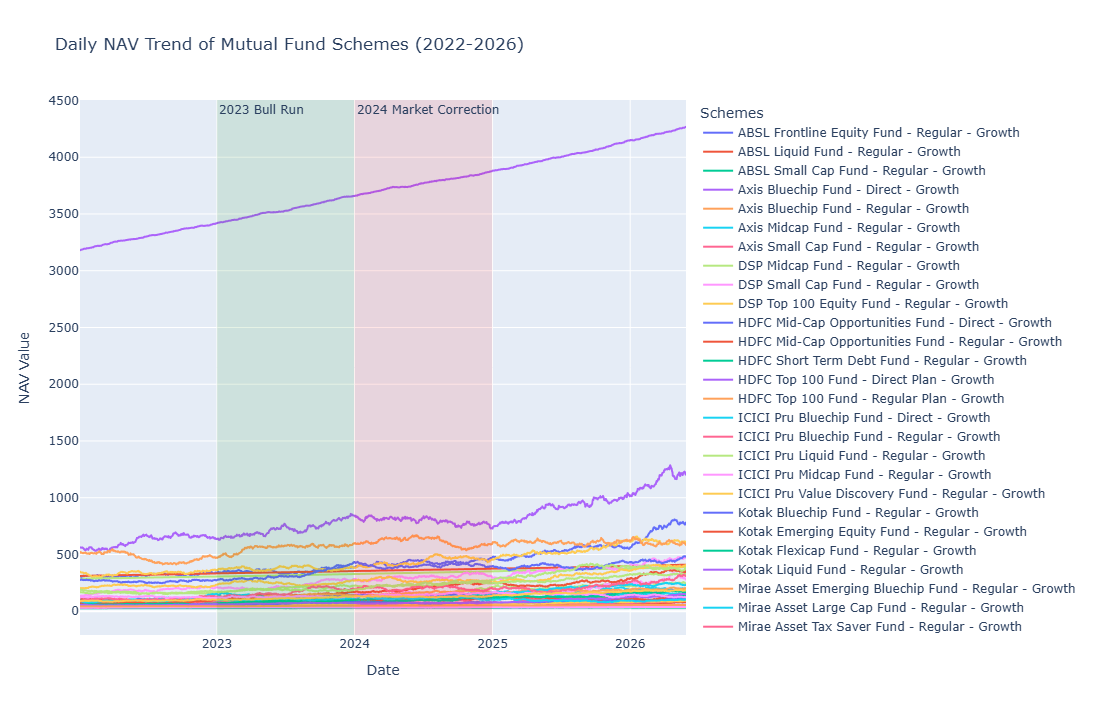

In [14]:
import plotly.express as px

# Create interactive NAV trend chart
fig = px.line(
    nav_data,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022-2026)",
    labels={
        "date": "Date",
        "nav": "NAV Value",
        "scheme_name": "Scheme"
    }
)

# Add 2023 Bull Run highlight
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.1,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Add 2024 Correction highlight
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.1,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

# Improve layout
fig.update_layout(
    height=700,
    width=1200,
    hovermode="x unified",
    legend_title_text="Schemes"
)

fig.show()

In [15]:
fig.write_html(
    "../reports/charts/NAV_daily_trend.html"
)

In [16]:
pip install kaleido

Note: you may need to restart the kernel to use updated packages.


In [18]:
fig.write_image(
    "../reports/charts/NAV_daily_trend.png"
)

In [19]:
import os

os.listdir("../data/processed")

['01_fund_master_clean.csv',
 '02_nav_history_clean.csv',
 '03_aum_by_fund_house_clean.csv',
 '04_monthly_sip_inflows_clean.csv',
 '05_category_inflows_clean.csv',
 '06_industry_folio_count_clean.csv',
 '07_scheme_performance_clean.csv',
 '08_investor_transactions_clean.csv',
 '09_portfolio_holdings_clean.csv',
 '10_benchmark_indices_clean.csv']

In [20]:


aum_data = pd.read_csv(
    "../data/processed/03_aum_by_fund_house_clean.csv"
)

aum_data.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [21]:
aum_data.shape

(90, 5)

In [22]:
aum_data.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')

In [23]:
aum_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     object 
 1   fund_house      90 non-null     object 
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 3.6+ KB


In [24]:
aum_data.head(10)

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168
5,2022-03-31,Aditya Birla Sun Life MF,2.78,278000,199
6,2022-03-31,Axis Mutual Fund,2.50,250000,95
7,2022-03-31,UTI Mutual Fund,2.30,230000,142
8,2022-03-31,Mirae Asset MF,1.05,105000,56
9,2022-03-31,DSP Mutual Fund,1.10,110000,88


In [25]:
aum_data.describe()

,aum_lakh_crore,aum_crore,num_schemes
count,90.000000,9.000000e+01,90.000000
mean,4.352889,4.352889e+05,152.200000
std,2.734328,2.734328e+05,52.108832
min,1.050000,1.050000e+05,56.000000
25%,2.525000,2.525000e+05,95.000000
50%,3.450000,3.450000e+05,172.500000
75%,5.675000,5.675000e+05,195.000000
max,12.500000,1.250000e+06,216.000000


<Axes: >

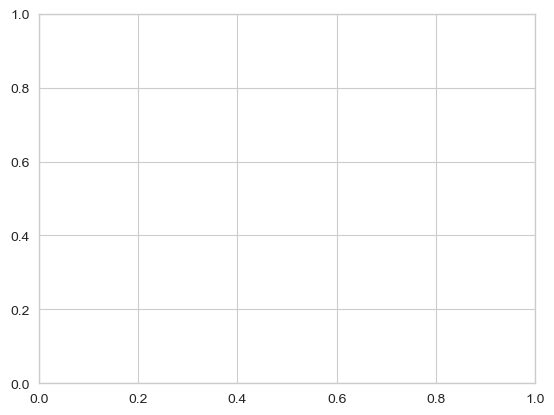

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot()

In [29]:
aum_data = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

aum_data.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [30]:
aum_data.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')

In [31]:
aum_data.shape

(90, 5)

In [32]:

aum_data["date"] = pd.to_datetime(aum_data["date"])

aum_data["year"] = aum_data["date"].dt.year
aum_filtered = aum_data[
    (aum_data["year"] >= 2022) &
    (aum_data["year"] <= 2025)
]

print("Filtered Shape:", aum_filtered.shape)

aum_filtered.head()

Filtered Shape: (90, 6)


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [33]:
aum_filtered["year"].value_counts()

year
2024    30
2022    20
2023    20
2025    20
Name: count, dtype: int64

In [34]:
aum_yearly = (
    aum_filtered
    .groupby(["fund_house", "year"])["aum_lakh_crore"]
    .max()
    .reset_index()
)

aum_yearly.head()

,fund_house,year,aum_lakh_crore
0,Aditya Birla Sun Life MF,2022,2.85
1,Aditya Birla Sun Life MF,2023,3.08
2,Aditya Birla Sun Life MF,2024,3.84
3,Aditya Birla Sun Life MF,2025,4.60
4,Axis Mutual Fund,2022,2.50


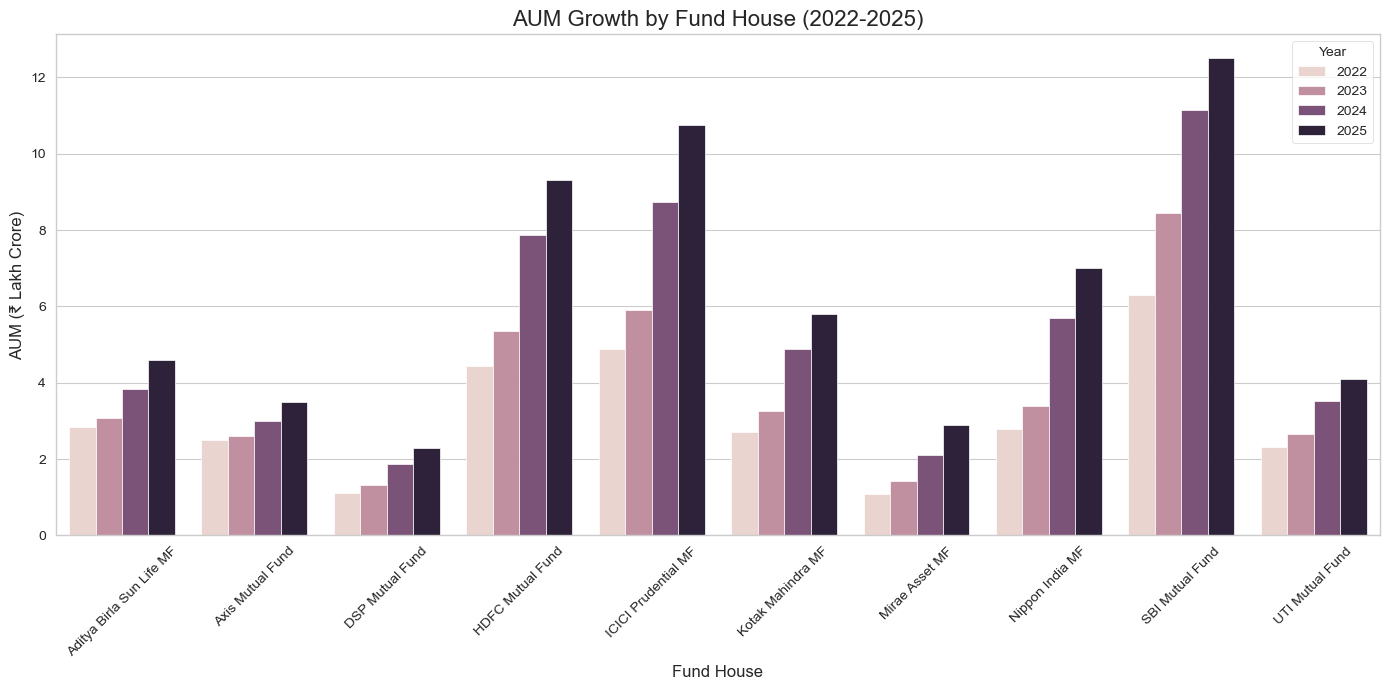

In [35]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum_yearly,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title(
    "AUM Growth by Fund House (2022-2025)",
    fontsize=16
)

plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")

plt.xticks(rotation=45)

plt.legend(
    title="Year"
)

plt.tight_layout()

plt.show()

In [36]:
aum_yearly[
    aum_yearly["fund_house"].str.contains("SBI", case=False)
]

,fund_house,year,aum_lakh_crore
32,SBI Mutual Fund,2022,6.30
33,SBI Mutual Fund,2023,8.45
34,SBI Mutual Fund,2024,11.14
35,SBI Mutual Fund,2025,12.50


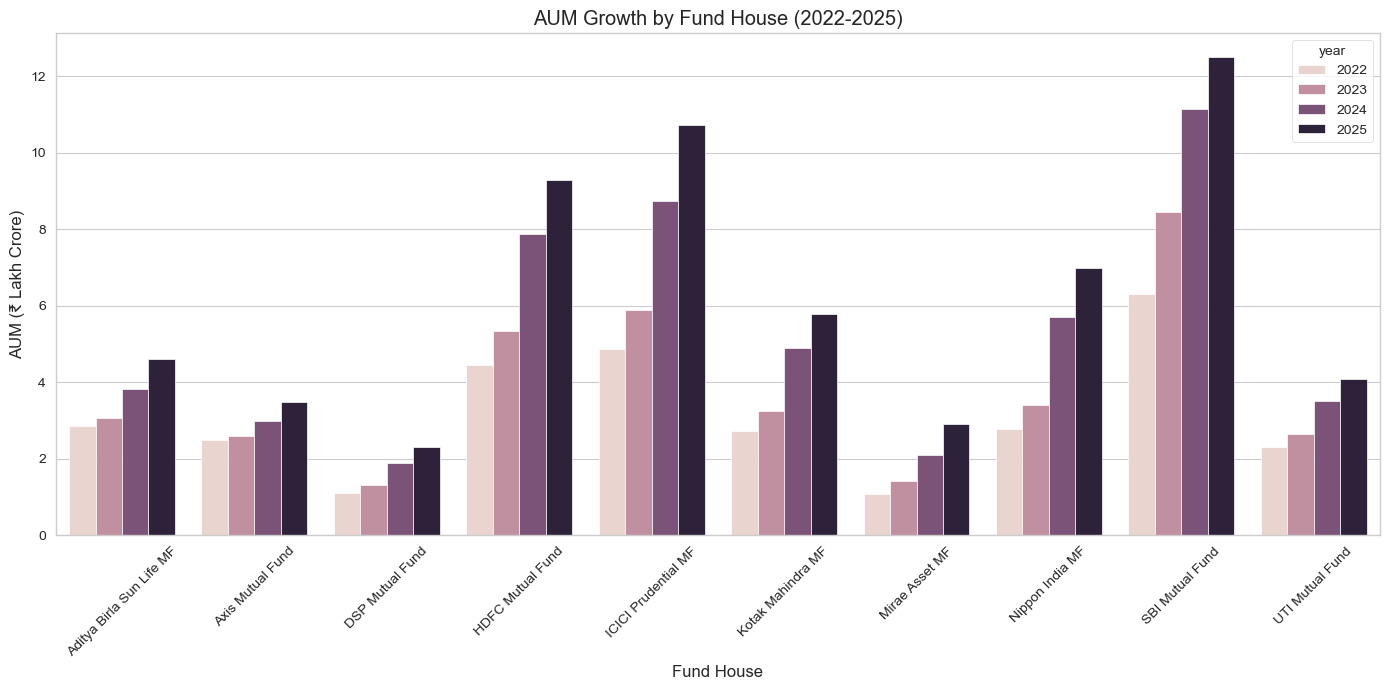

In [37]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=aum_yearly,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title(
    "AUM Growth by Fund House (2022-2025)"
)

plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [38]:
aum_filtered.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [39]:
# ==========================================================
# Aggregate AUM by Fund House and Year
# ==========================================================

aum_yearly = (
    aum_filtered
    .groupby(["fund_house", "year"])["aum_lakh_crore"]
    .max()
    .reset_index()
)

aum_yearly.head(10)

,fund_house,year,aum_lakh_crore
0,Aditya Birla Sun Life MF,2022,2.85
1,Aditya Birla Sun Life MF,2023,3.08
2,Aditya Birla Sun Life MF,2024,3.84
3,Aditya Birla Sun Life MF,2025,4.60
4,Axis Mutual Fund,2022,2.50
5,Axis Mutual Fund,2023,2.60
6,Axis Mutual Fund,2024,3.00
7,Axis Mutual Fund,2025,3.50
8,DSP Mutual Fund,2022,1.12
9,DSP Mutual Fund,2023,1.32


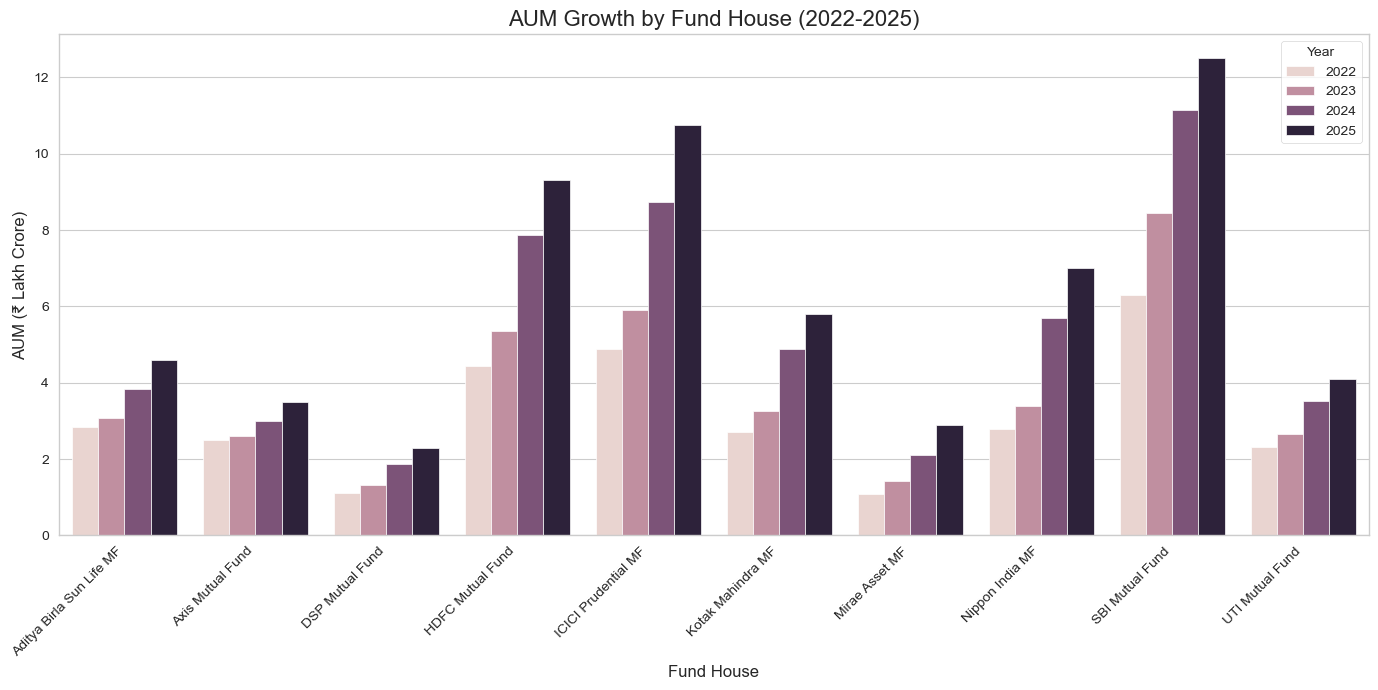

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=aum_yearly,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title(
    "AUM Growth by Fund House (2022-2025)",
    fontsize=16
)

plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")

plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Year"
)

plt.tight_layout()

plt.show()

In [44]:
aum_yearly[
    aum_yearly["fund_house"].str.contains("SBI", case=False)
]

,fund_house,year,aum_lakh_crore
32,SBI Mutual Fund,2022,6.30
33,SBI Mutual Fund,2023,8.45
34,SBI Mutual Fund,2024,11.14
35,SBI Mutual Fund,2025,12.50


In [46]:
aum_yearly["year"] = aum_yearly["year"].astype(str)

aum_yearly["aum_lakh_crore"] = pd.to_numeric(
    aum_yearly["aum_lakh_crore"],
    errors="coerce"
)

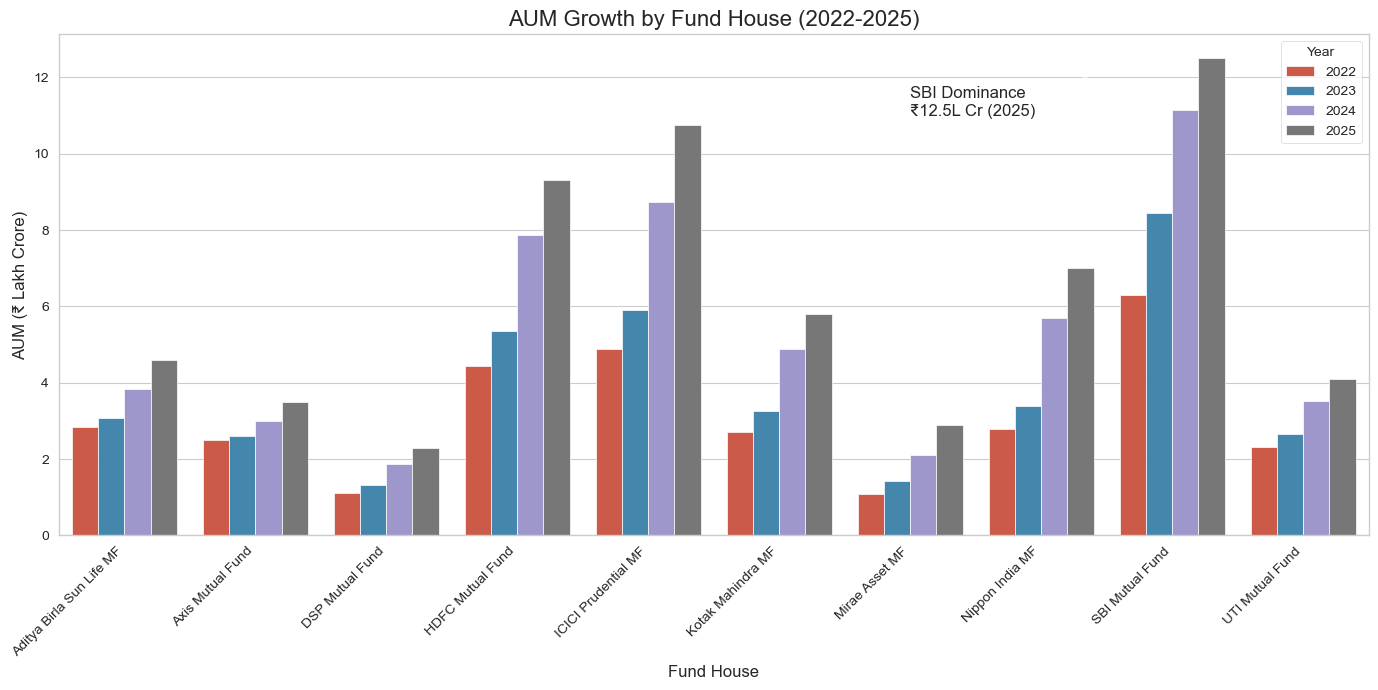

In [48]:
plt.annotate(
    "SBI Dominance\n₹12.5L Cr (2025)",
    xy=(8,12.5),
    xytext=(6,11),
    arrowprops=dict(
        arrowstyle="->"
    ),
    fontsize=12
)

In [49]:
aum_yearly["fund_house"].unique()

array(['Aditya Birla Sun Life MF', 'Axis Mutual Fund', 'DSP Mutual Fund',
       'HDFC Mutual Fund', 'ICICI Prudential MF', 'Kotak Mahindra MF',
       'Mirae Asset MF', 'Nippon India MF', 'SBI Mutual Fund',
       'UTI Mutual Fund'], dtype=object)

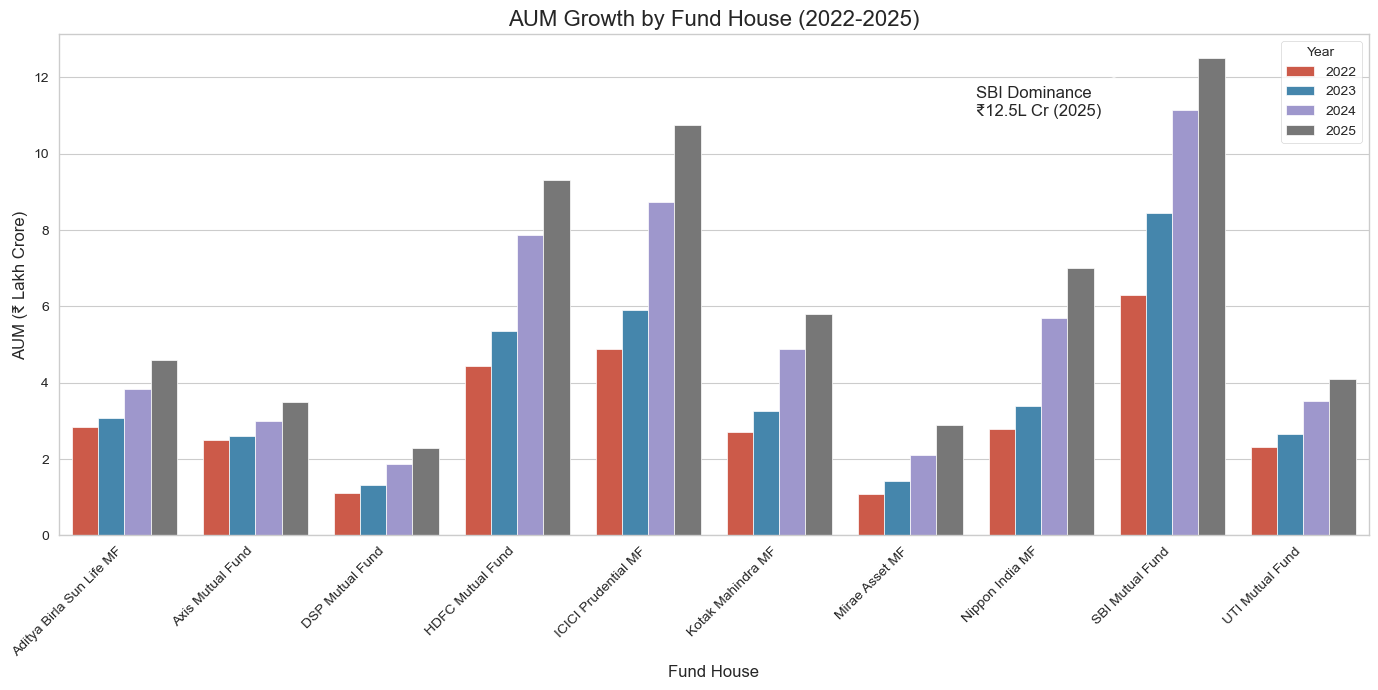

In [51]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=aum_yearly,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title(
    "AUM Growth by Fund House (2022-2025)",
    fontsize=16
)

plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")

plt.xticks(rotation=45, ha="right")


# SBI Highlight
plt.annotate(
    "SBI Dominance\n₹12.5L Cr (2025)",
    xy=(8,12.5),
    xytext=(6.5,11),
    arrowprops=dict(
        arrowstyle="->"
    ),
    fontsize=12
)

plt.legend(title="Year")

plt.tight_layout()

plt.show()

In [52]:
df_sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")

In [53]:
df_sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [54]:
df_sip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     object 
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 2.4+ KB


In [55]:
df_sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')

In [56]:
df_sip["month"] = pd.to_datetime(df_sip["month"])

In [57]:
filtered_sip = df_sip[
    (df_sip["month"] >= "2022-01-01") &
    (df_sip["month"] <= "2025-12-31")
]

In [58]:
filtered_sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [59]:
filtered_sip.tail()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
43,2025-08-01,28265,8.85,9.80,15.18,20.04
44,2025-09-01,29361,9.00,10.50,15.38,19.80
45,2025-10-01,29529,9.10,9.45,15.55,16.61
46,2025-11-01,30200,9.20,9.10,15.72,19.27
47,2025-12-01,31002,9.35,9.80,15.90,17.17


In [62]:
peak = filtered_sip.loc[
    filtered_sip["sip_inflow_crore"].idxmax()
]

peak

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [63]:
print("Peak SIP Inflow Details")
print("-" * 40)
print(f"Month            : {peak['month'].strftime('%B %Y')}")
print(f"SIP Inflow       : ₹{peak['sip_inflow_crore']:,.0f} Crore")
print(f"Active SIP A/Cs  : {peak['active_sip_accounts_crore']} Crore")
print(f"New SIP A/Cs     : {peak['new_sip_accounts_lakh']} Lakh")
print(f"SIP AUM          : ₹{peak['sip_aum_lakh_crore']} Lakh Crore")
print(f"YoY Growth       : {peak['yoy_growth_pct']} %")

Peak SIP Inflow Details
----------------------------------------
Month            : December 2025
SIP Inflow       : ₹31,002 Crore
Active SIP A/Cs  : 9.35 Crore
New SIP A/Cs     : 9.8 Lakh
SIP AUM          : ₹15.9 Lakh Crore
YoY Growth       : 17.17 %


In [65]:
import plotly.express as px
fig = px.line(
    filtered_sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Growth (Jan 2022 - Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

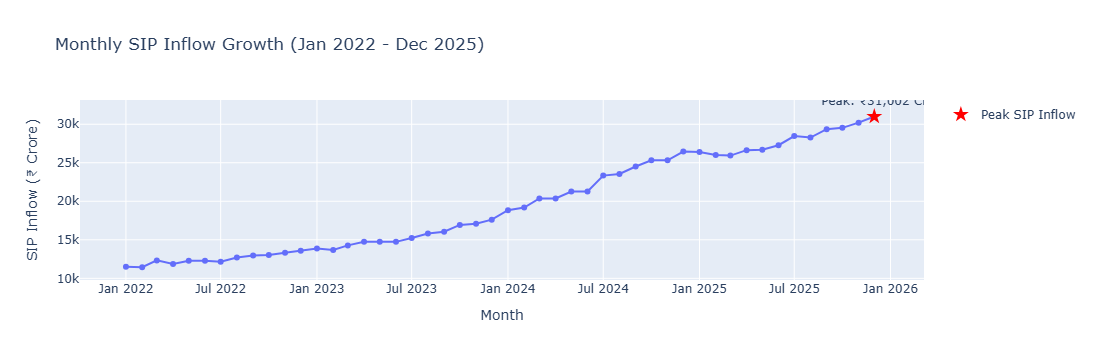

In [66]:
fig.add_scatter(
    x=[peak["month"]],
    y=[peak["sip_inflow_crore"]],
    mode="markers+text",
    text=["Peak: ₹31,002 Cr"],
    textposition="top center",
    marker=dict(size=12, color="red", symbol="star"),
    name="Peak SIP Inflow"
)

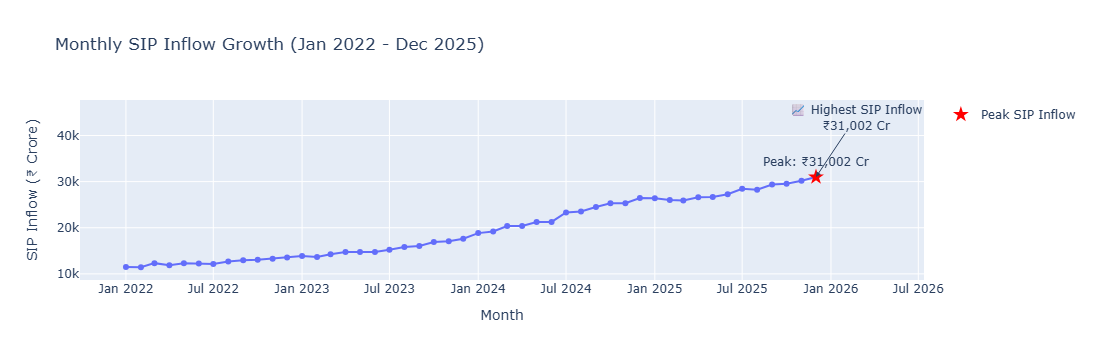

In [67]:
fig.add_annotation(
    x=peak["month"],
    y=peak["sip_inflow_crore"],
    text="📈 Highest SIP Inflow<br>₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    ax=40,
    ay=-60
)

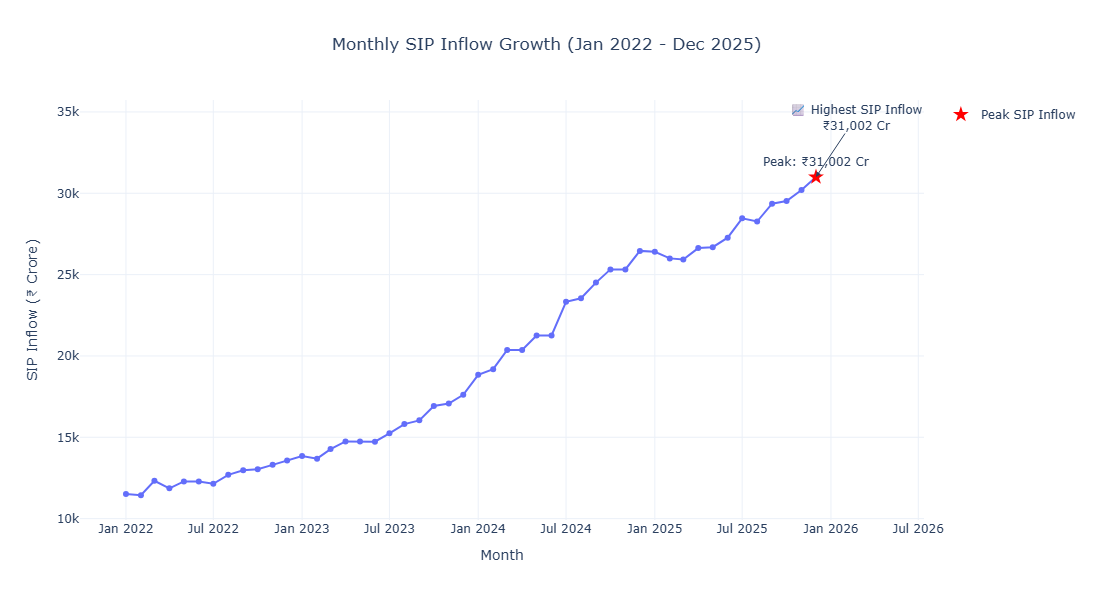

In [68]:
fig.update_layout(
    template="plotly_white",
    height=600,
    width=1000,
    hovermode="x unified",
    title_x=0.5,
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

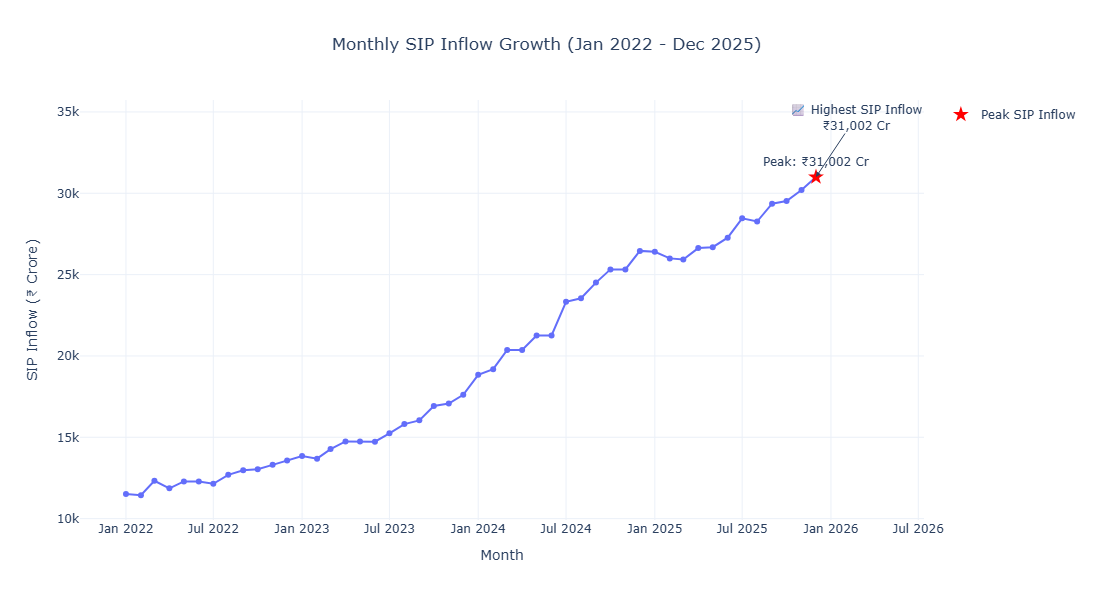

In [69]:
fig.show()

In [70]:
fig.write_html("../reports/charts/SIP_inflow_trend.html")

In [72]:
import pandas as pd

df_fund = pd.read_csv("../data/processed/01_fund_master_clean.csv")

In [73]:
df_fund.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [74]:
df_fund.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     object 
 2   scheme_name         40 non-null     object 
 3   category            40 non-null     object 
 4   sub_category        40 non-null     object 
 5   plan                40 non-null     object 
 6   launch_date         40 non-null     object 
 7   benchmark           40 non-null     object 
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     object 
 13  risk_category       40 non-null     object 
 14  sebi_category_code  40 non-null     object 
dtypes: float64(2), int64(3), object(10)
memory usage: 4.8+ KB


In [75]:
df_fund.columns.tolist()

['amfi_code',
 'fund_house',
 'scheme_name',
 'category',
 'sub_category',
 'plan',
 'launch_date',
 'benchmark',
 'expense_ratio_pct',
 'exit_load_pct',
 'min_sip_amount',
 'min_lumpsum_amount',
 'fund_manager',
 'risk_category',
 'sebi_category_code']

In [77]:
fund_house_count = (
    df_fund
    .groupby("fund_house")
    .size()
    .reset_index(name="scheme_count")
    .sort_values(by="scheme_count", ascending=False)
)

fund_house_count.head(10)

,fund_house,scheme_count
3,HDFC Mutual Fund,5
4,ICICI Prudential MF,5
7,Nippon India MF,5
8,SBI Mutual Fund,5
1,Axis Mutual Fund,4
5,Kotak Mahindra MF,4
0,Aditya Birla Sun Life MF,3
2,DSP Mutual Fund,3
6,Mirae Asset MF,3
9,UTI Mutual Fund,3


In [78]:
import plotly.express as px

fig = px.bar(
    fund_house_count.head(10),
    x="scheme_count",
    y="fund_house",
    orientation="h",
    text="scheme_count",
    title="Top 10 Fund Houses by Number of Schemes"
)

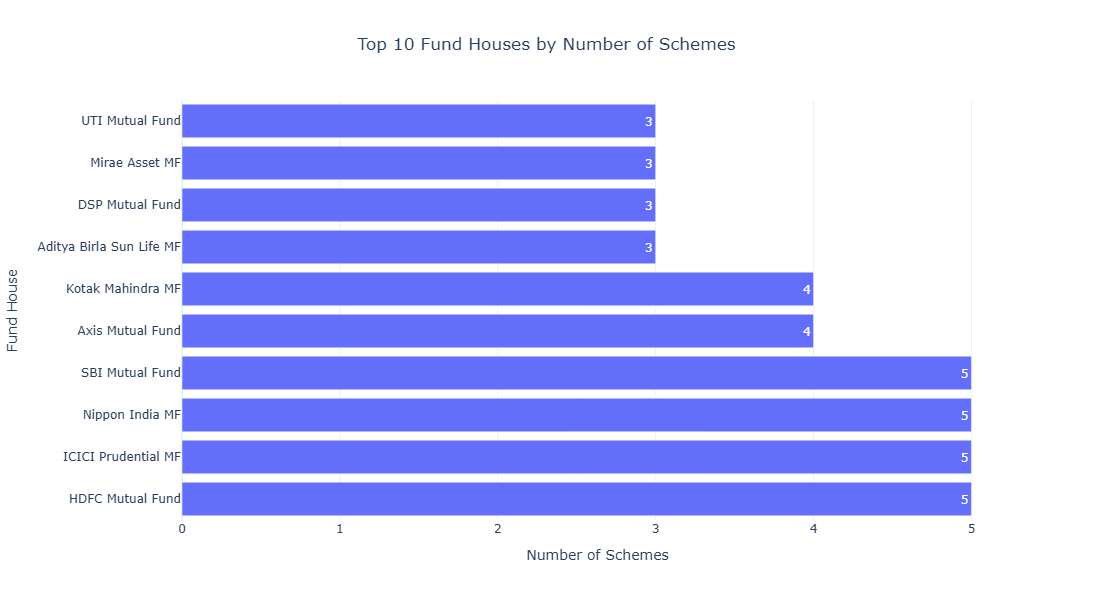

In [79]:
fig.update_layout(
    template="plotly_white",
    height=600,
    width=1000,
    title_x=0.5,
    xaxis_title="Number of Schemes",
    yaxis_title="Fund House"
)

In [81]:
fig.write_html("../reports/charts/Fund_House_Distribution.html")

In [82]:
category_count = (
    df_fund
    .groupby("category")
    .size()
    .reset_index(name="scheme_count")
    .sort_values(by="scheme_count", ascending=False)
)

category_count

,category,scheme_count
1,Equity,34
0,Debt,6


In [83]:
fig = px.pie(
    category_count,
    names="category",
    values="scheme_count",
    title="Scheme Distribution by Category"
)

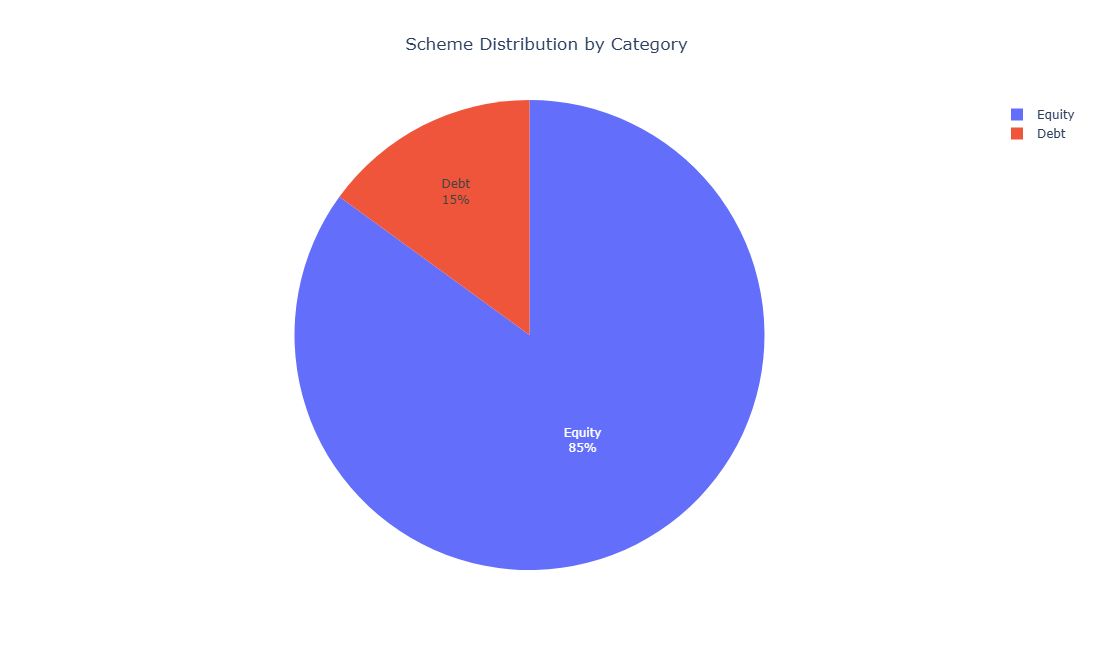

In [84]:
fig.update_traces(textposition="inside", textinfo="percent+label")

fig.update_layout(
    template="plotly_white",
    height=650,
    width=900,
    title_x=0.5
)

In [86]:
fig.write_html("../reports/charts/Category_Distribution.html")

In [87]:
risk_count = (
    df_fund
    .groupby("risk_category")
    .size()
    .reset_index(name="scheme_count")
    .sort_values(by="scheme_count", ascending=False)
)

risk_count

,risk_category,scheme_count
2,Moderate,16
0,High,8
1,Low,6
4,Very High,6
3,Moderately High,4


In [88]:
fig = px.bar(
    risk_count,
    x="risk_category",
    y="scheme_count",
    text="scheme_count",
    title="Distribution of Mutual Fund Schemes by Risk Category"
)

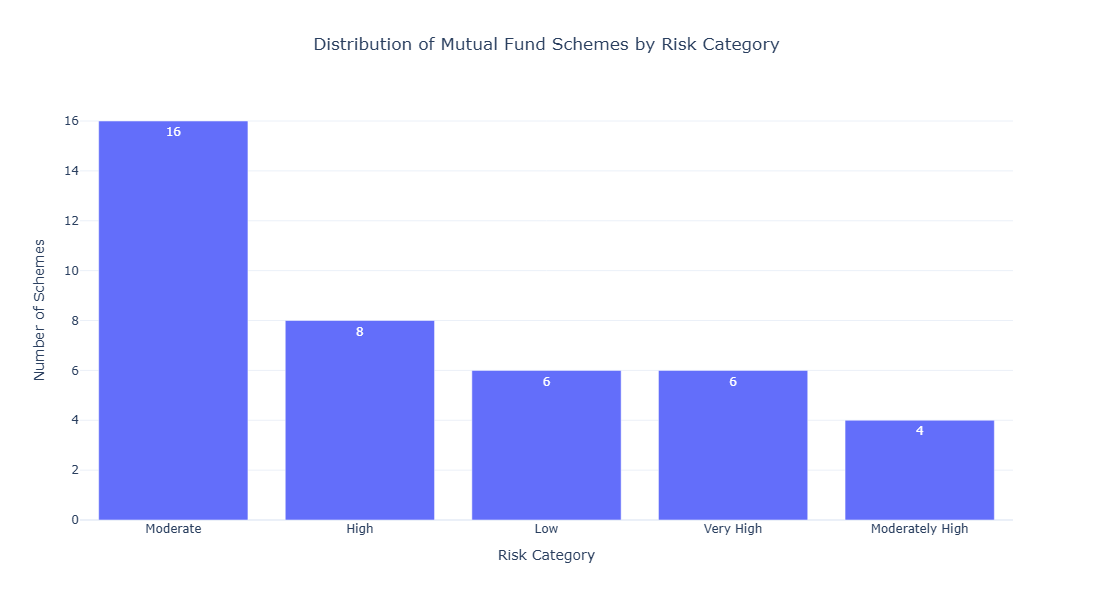

In [90]:
fig.update_layout(
    template="plotly_white",
    height=600,
    width=1000,
    title_x=0.5,
    xaxis_title="Risk Category",
    yaxis_title="Number of Schemes"
)

In [91]:
fig.write_html("../reports/charts/Risk_Category_Distribution.html")

In [92]:
df_category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

In [93]:
df_category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [94]:
df_category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    object 
 1   category          144 non-null    object 
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.5+ KB


In [95]:
df_category.columns.tolist()

['month', 'category', 'net_inflow_crore']

In [96]:
df_category["month"] = pd.to_datetime(df_category["month"])

In [97]:
df_category = df_category.sort_values("month")

In [100]:
category_pivot = df_category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

category_pivot.head()

month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


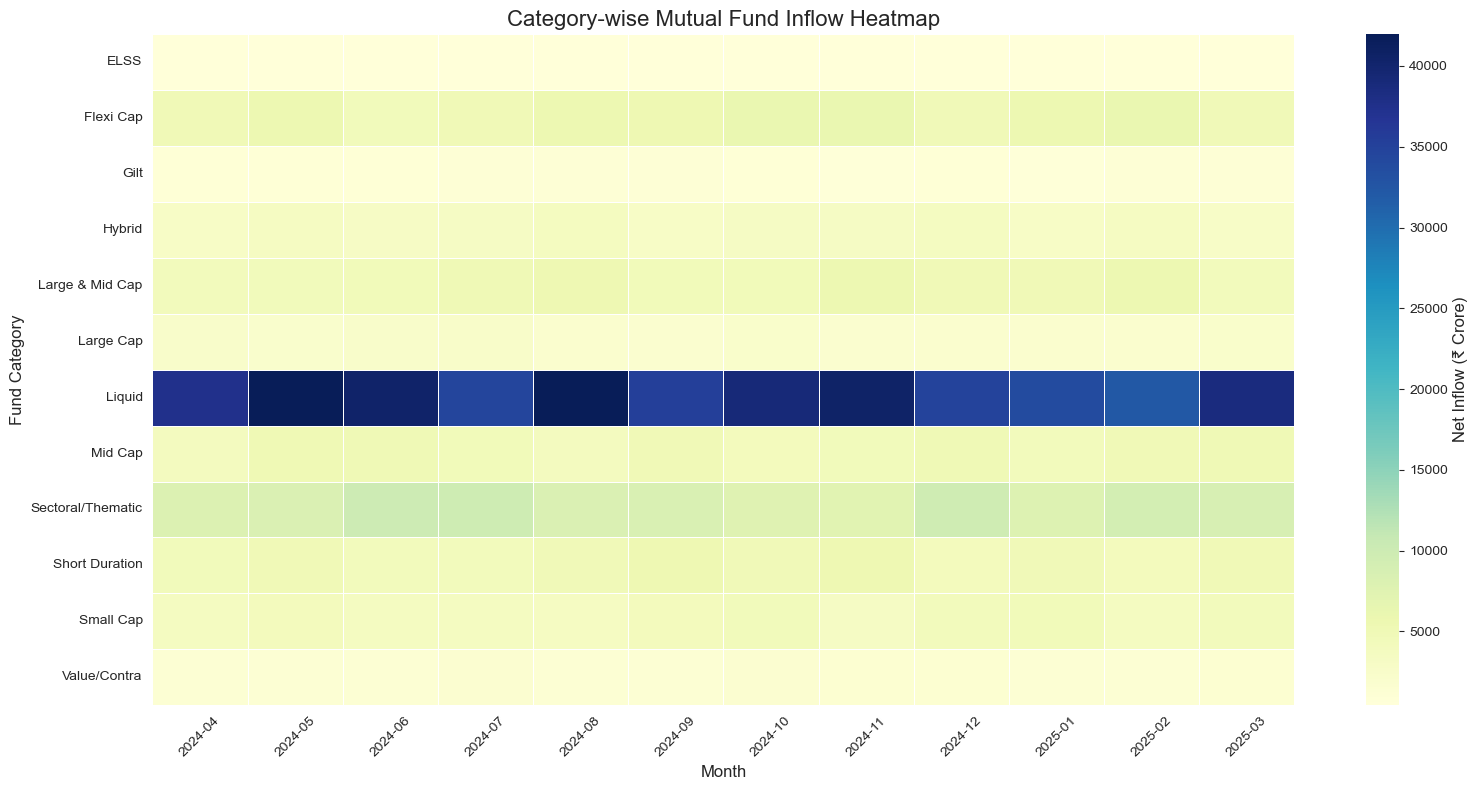

In [101]:
plt.figure(figsize=(16,8))

sns.heatmap(
    category_pivot,
    cmap="YlGnBu",
    annot=False,
    linewidths=0.5,
    cbar_kws={
        "label": "Net Inflow (₹ Crore)"
    }
)

plt.title(
    "Category-wise Mutual Fund Inflow Heatmap",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

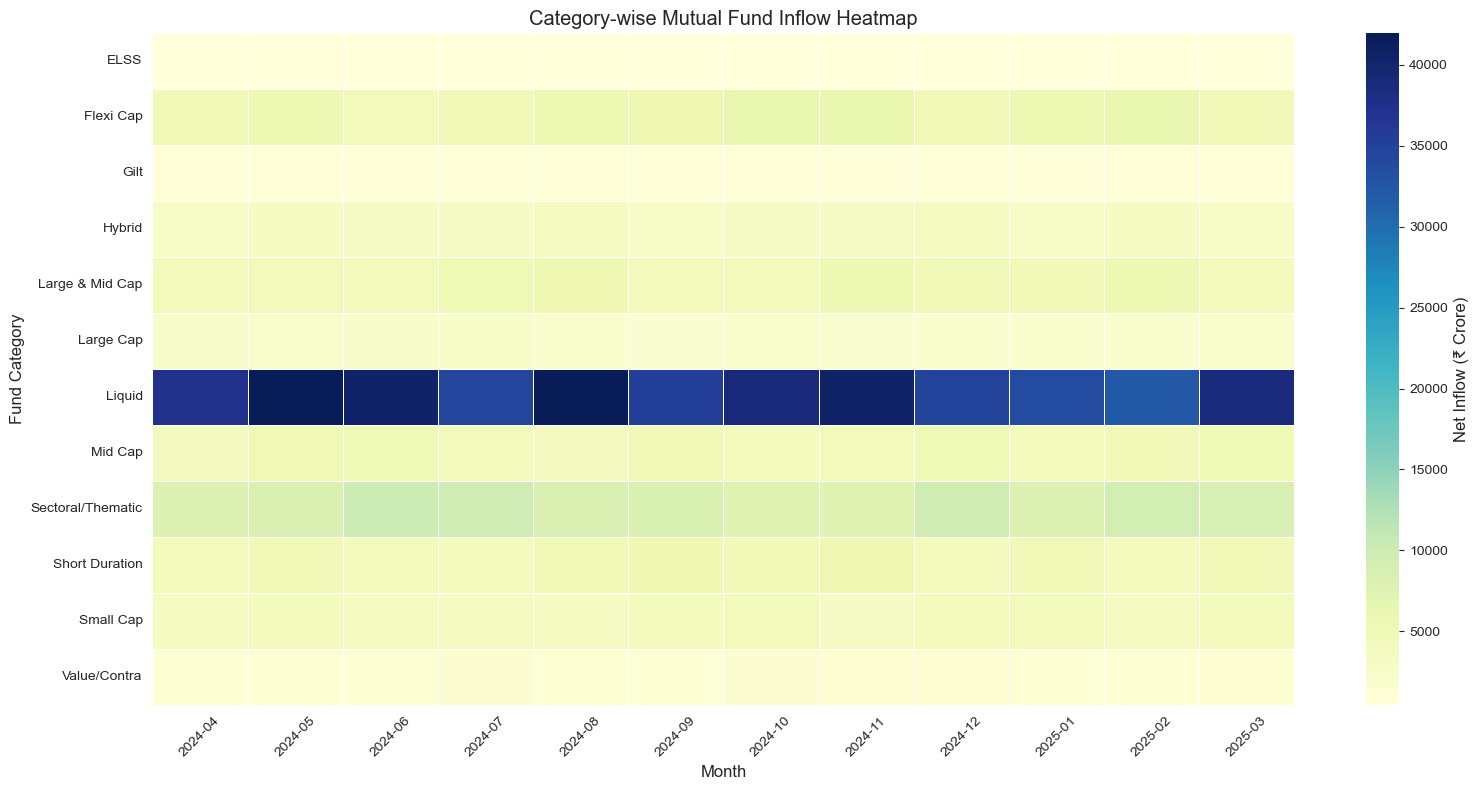

In [102]:
plt.figure(figsize=(16,8))

sns.heatmap(
    category_pivot,
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={
        "label": "Net Inflow (₹ Crore)"
    }
)

plt.title("Category-wise Mutual Fund Inflow Heatmap")

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/charts/Category_Inflow_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [103]:
df_category.columns.tolist()

['month', 'category', 'net_inflow_crore']

In [105]:
import pandas as pd

df_investor = pd.read_csv(
    "../data/processed/08_investor_transactions_clean.csv"
)

df_investor.head()


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [106]:
df_investor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  object 
 1   transaction_date    32778 non-null  object 
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  object 
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  object 
 6   city                32778 non-null  object 
 7   city_tier           32778 non-null  object 
 8   age_group           32778 non-null  object 
 9   gender              32778 non-null  object 
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  object 
 12  kyc_status          32778 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.3+ MB


In [107]:
df_investor.columns.tolist()

['investor_id',
 'transaction_date',
 'amfi_code',
 'transaction_type',
 'amount_inr',
 'state',
 'city',
 'city_tier',
 'age_group',
 'gender',
 'annual_income_lakh',
 'payment_mode',
 'kyc_status']

In [108]:
df_investor.isnull().sum()

investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64

In [109]:
age_distribution = (
    df_investor
    .groupby("age_group")
    .size()
    .reset_index(name="investor_count")
)

age_distribution

,age_group,investor_count
0,18-25,4916
1,26-35,13463
2,36-45,8146
3,46-55,3779
4,56+,2474


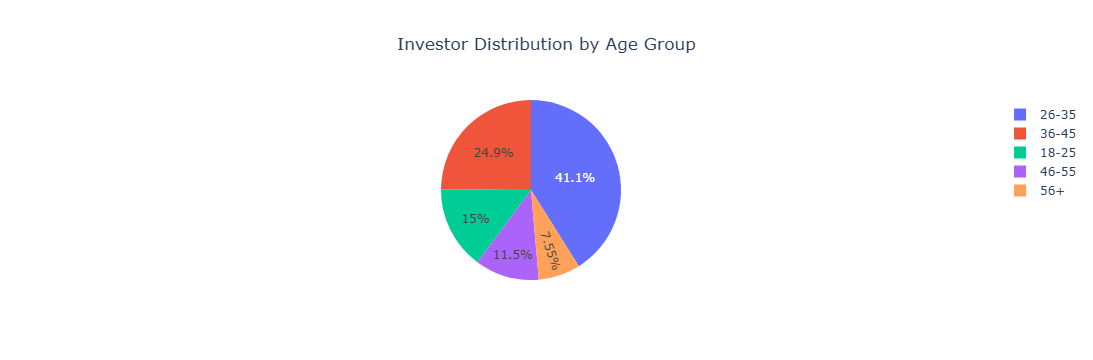

In [110]:
fig = px.pie(
    age_distribution,
    names="age_group",
    values="investor_count",
    title="Investor Distribution by Age Group"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

In [111]:
fig.write_html(
    "../reports/charts/Age_Group_Distribution.html"
)

In [112]:
sip_data = df_investor[
    df_investor["transaction_type"]=="SIP"
]

In [113]:
sip_data.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified


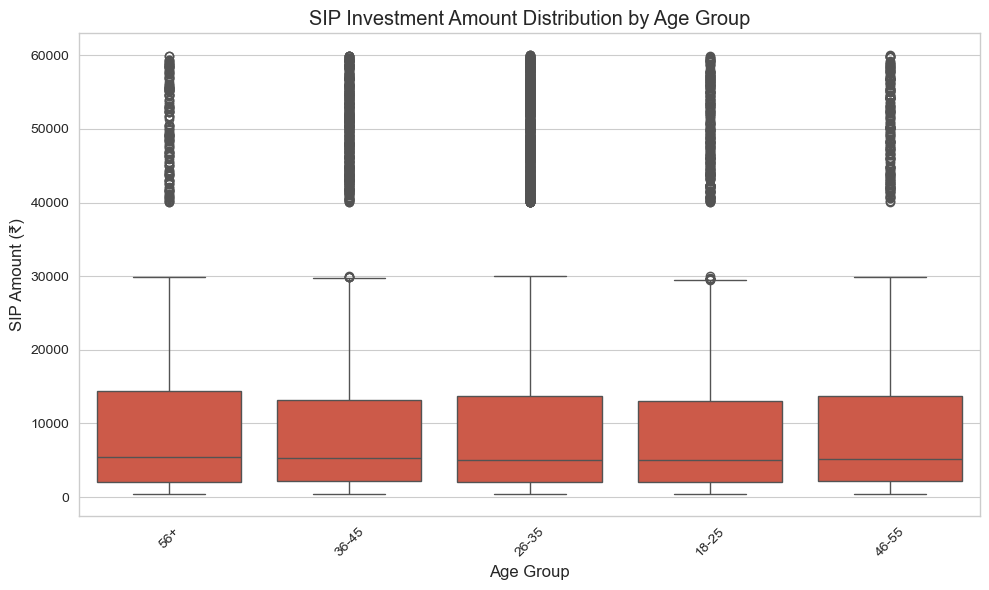

In [116]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_data,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "SIP Investment Amount Distribution by Age Group"
)

plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/charts/SIP_Amount_By_Age_Group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [117]:
gender_distribution = (
    df_investor
    .groupby("gender")
    .size()
    .reset_index(name="investor_count")
)

gender_distribution

,gender,investor_count
0,Female,10969
1,Male,21809


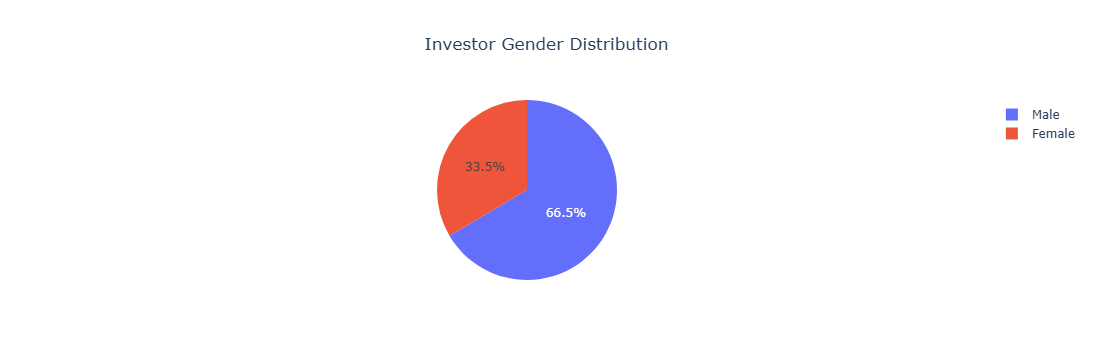

In [118]:
fig = px.pie(
    gender_distribution,
    names="gender",
    values="investor_count",
    title="Investor Gender Distribution"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

In [119]:
fig.write_html(
    "../reports/charts/Gender_Distribution.html"
)

In [121]:
df_geo = pd.read_csv(
    "../data/processed/08_investor_transactions_clean.csv"
)

df_geo.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [122]:
sip_geo = df_geo[
    df_geo["transaction_type"] == "SIP"
]

In [123]:
state_sip = (
    sip_geo
    .groupby("state")["amount_inr"]
    .sum()
    .reset_index()
    .sort_values(
        by="amount_inr",
        ascending=False
    )
)

state_sip.head(10)

,state,amount_inr
4,Madhya Pradesh,20682243
6,Punjab,20140064
9,Telangana,18620216
8,Tamil Nadu,18404368
1,Gujarat,18378904
2,Haryana,18176696
3,Karnataka,17696903
10,Uttar Pradesh,17534858
11,West Bengal,17495769
0,Delhi,17113608


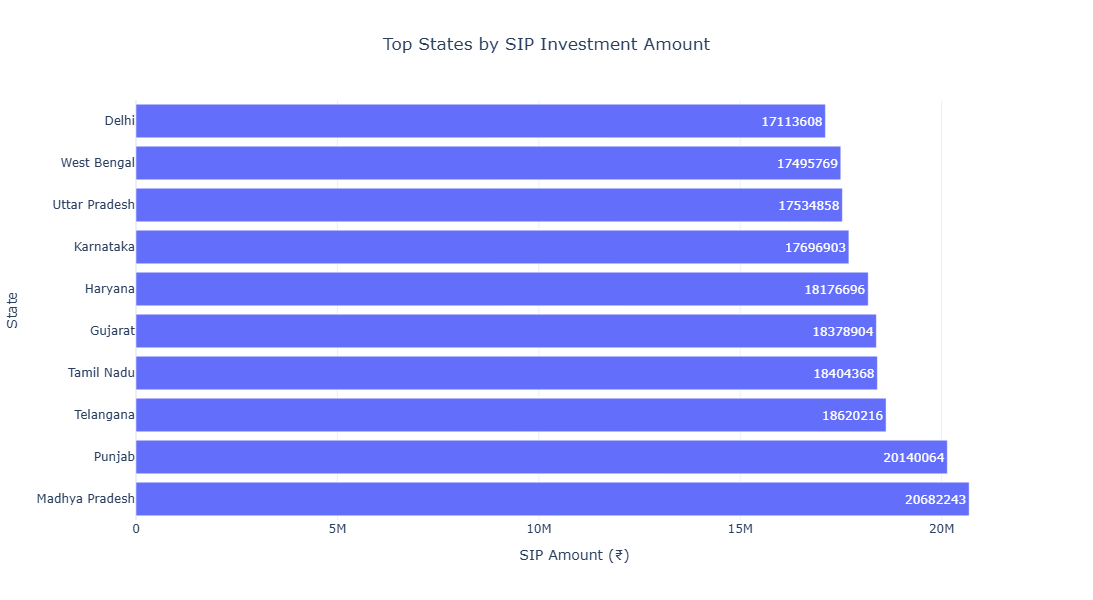

In [124]:
fig = px.bar(
    state_sip.head(10),
    x="amount_inr",
    y="state",
    orientation="h",
    text="amount_inr",
    title="Top States by SIP Investment Amount"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="SIP Amount (₹)",
    yaxis_title="State",
    height=600
)

fig.show()

In [125]:
fig.write_html(
    "../reports/charts/State_wise_SIP_Amount.html"
)

In [126]:
city_tier_distribution = (
    df_geo
    .groupby("city_tier")
    .size()
    .reset_index(name="investor_count")
)

city_tier_distribution

,city_tier,investor_count
0,B30,11059
1,T30,21719


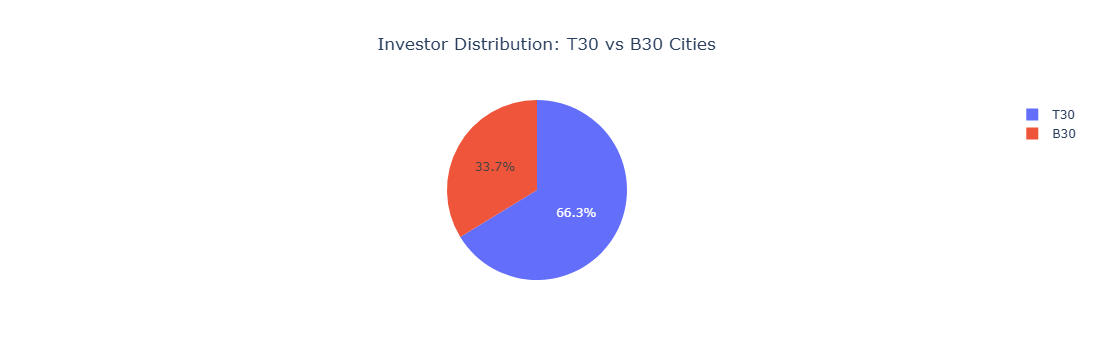

In [127]:
fig = px.pie(
    city_tier_distribution,
    names="city_tier",
    values="investor_count",
    title="Investor Distribution: T30 vs B30 Cities"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

In [128]:
fig.write_html(
    "../reports/charts/T30_B30_Distribution.html"
)

In [129]:
import pandas as pd

df_folio = pd.read_csv(
    "../data/processed/06_industry_folio_count_clean.csv"
)

df_folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [131]:
df_folio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     object 
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), object(1)
memory usage: 1.1+ KB


In [132]:
df_folio.columns.tolist()

['month',
 'total_folios_crore',
 'equity_folios_crore',
 'debt_folios_crore',
 'hybrid_folios_crore',
 'others_folios_crore']

In [133]:
df_folio["month"] = pd.to_datetime(df_folio["month"])

In [134]:
df_folio = df_folio.sort_values("month")

In [135]:
print("Start Date:", df_folio["month"].min())
print("End Date:", df_folio["month"].max())

Start Date: 2022-01-01 00:00:00
End Date: 2025-12-01 00:00:00


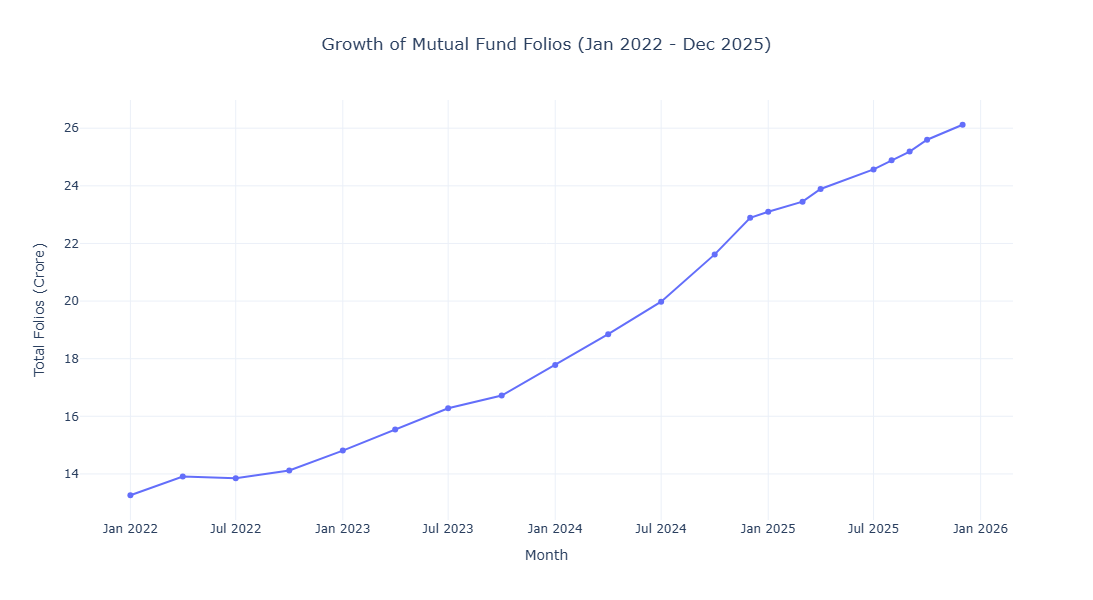

In [136]:
fig = px.line(
    df_folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Growth of Mutual Fund Folios (Jan 2022 - Dec 2025)",
    labels={
        "month": "Month",
        "total_folios_crore": "Total Folios (Crore)"
    }
)

fig.update_layout(
    template="plotly_white",
    height=600,
    width=1000,
    title_x=0.5,
    hovermode="x unified"
)

fig.show()

In [137]:
start_point = df_folio.iloc[0]

end_point = df_folio.iloc[-1]

print(start_point)
print(end_point)

month                  2022-01-01 00:00:00
total_folios_crore                   13.26
equity_folios_crore                   9.28
debt_folios_crore                     1.86
hybrid_folios_crore                    0.8
others_folios_crore                   1.33
Name: 0, dtype: object
month                  2025-12-01 00:00:00
total_folios_crore                   26.12
equity_folios_crore                  18.28
debt_folios_crore                     3.66
hybrid_folios_crore                   1.57
others_folios_crore                   2.61
Name: 20, dtype: object


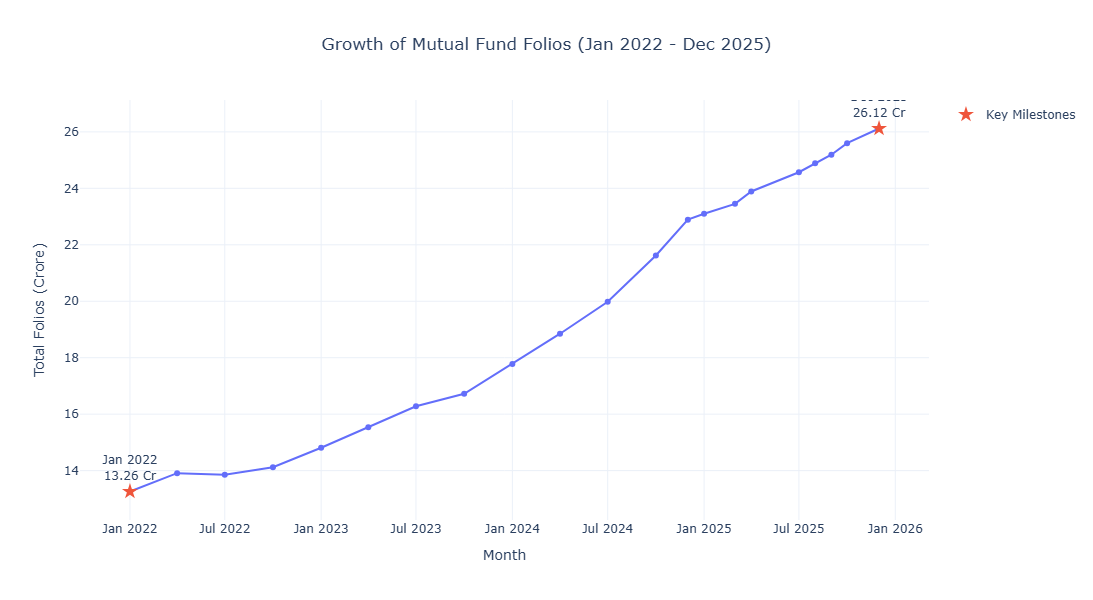

In [138]:
fig.add_scatter(
    x=[
        start_point["month"],
        end_point["month"]
    ],
    y=[
        start_point["total_folios_crore"],
        end_point["total_folios_crore"]
    ],
    mode="markers+text",
    text=[
        "Jan 2022<br>13.26 Cr",
        "Dec 2025<br>26.12 Cr"
    ],
    textposition="top center",
    marker=dict(
        size=12,
        symbol="star"
    ),
    name="Key Milestones"
)

fig.show()

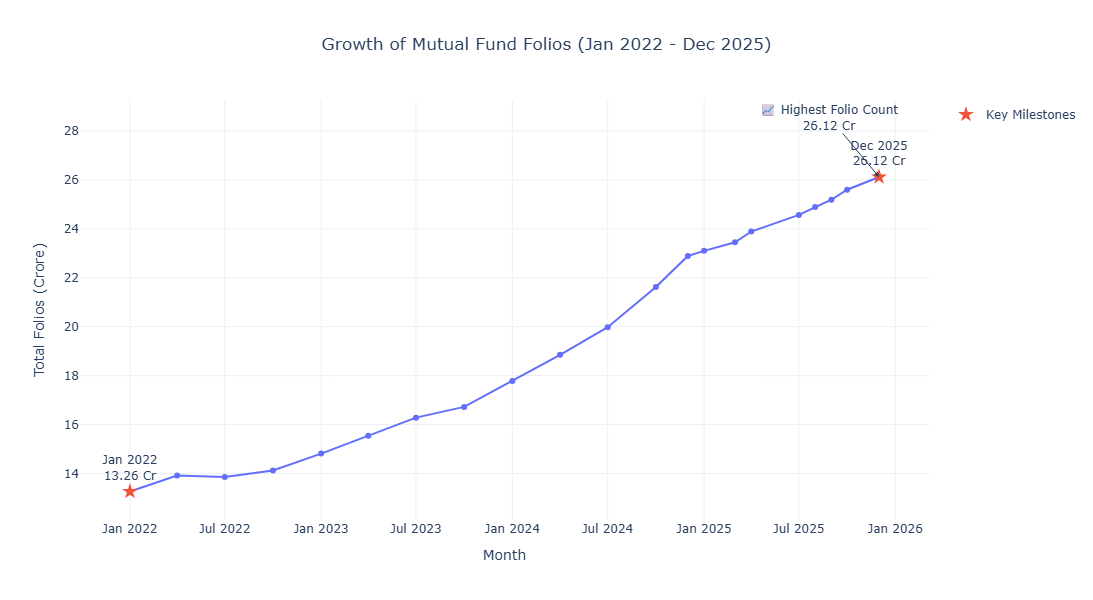

In [139]:
fig.add_annotation(
    x=end_point["month"],
    y=end_point["total_folios_crore"],
    text="📈 Highest Folio Count<br>26.12 Cr",
    showarrow=True,
    arrowhead=2,
    ax=-50,
    ay=-60
)

fig.show()

In [140]:
os.makedirs("../reports/charts", exist_ok=True)

fig.write_html(
    "../reports/charts/Folio_Count_Growth.html"
)

In [141]:
df_nav = pd.read_csv(
    "../data/processed/02_nav_history_clean.csv"
)

df_nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [142]:
df_nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [143]:
df_nav.columns.tolist()

['amfi_code', 'date', 'nav']

In [144]:
df_nav["date"] = pd.to_datetime(df_nav["date"])

In [145]:
df_nav["amfi_code"].nunique()

40

In [146]:
selected_funds = (
    df_nav["amfi_code"]
    .unique()[:10]
)

selected_funds

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632])

In [147]:
df_selected_nav = df_nav[
    df_nav["amfi_code"].isin(selected_funds)
]

df_selected_nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [148]:
nav_pivot = df_selected_nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

nav_pivot.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [149]:
nav_returns = nav_pivot.pct_change()

nav_returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [150]:
nav_returns = nav_returns.dropna()

In [151]:
correlation_matrix = nav_returns.corr()

correlation_matrix

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


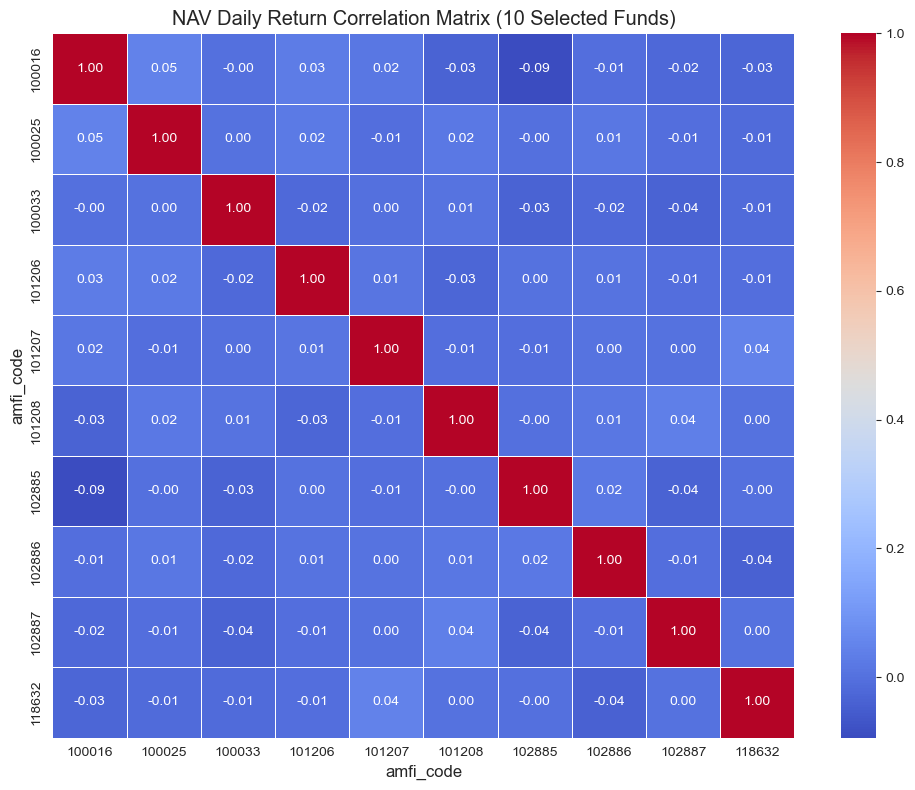

In [153]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "NAV Daily Return Correlation Matrix (10 Selected Funds)"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/NAV_Return_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [154]:
import pandas as pd

df_holdings = pd.read_csv(
    "../data/processed/09_portfolio_holdings_clean.csv"
)

df_holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [155]:
df_holdings.columns.tolist()

['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

In [156]:
df_holdings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    object 
 2   stock_name         322 non-null    object 
 3   sector             322 non-null    object 
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 20.3+ KB


In [157]:
df_holdings["sector"].value_counts()

sector
Banking           60
IT                40
Pharma            38
Automobile        33
Utilities         24
Infrastructure    22
FMCG              21
Telecom           15
Diversified       14
Energy            13
Cement            12
NBFC              11
Paints            10
Consumer Goods     9
Name: count, dtype: int64

In [158]:
sector_allocation = (
    df_holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .reset_index()
    .sort_values(
        by="weight_pct",
        ascending=False
    )
)

sector_allocation

,sector,weight_pct
1,Banking,652.26
7,IT,455.47
11,Pharma,407.45
0,Automobile,323.65
13,Utilities,265.54
6,FMCG,229.11
8,Infrastructure,192.16
4,Diversified,169.23
12,Telecom,145.62
3,Consumer Goods,127.61


In [159]:
sector_allocation["weight_pct"].sum()

np.float64(3399.9900000000002)

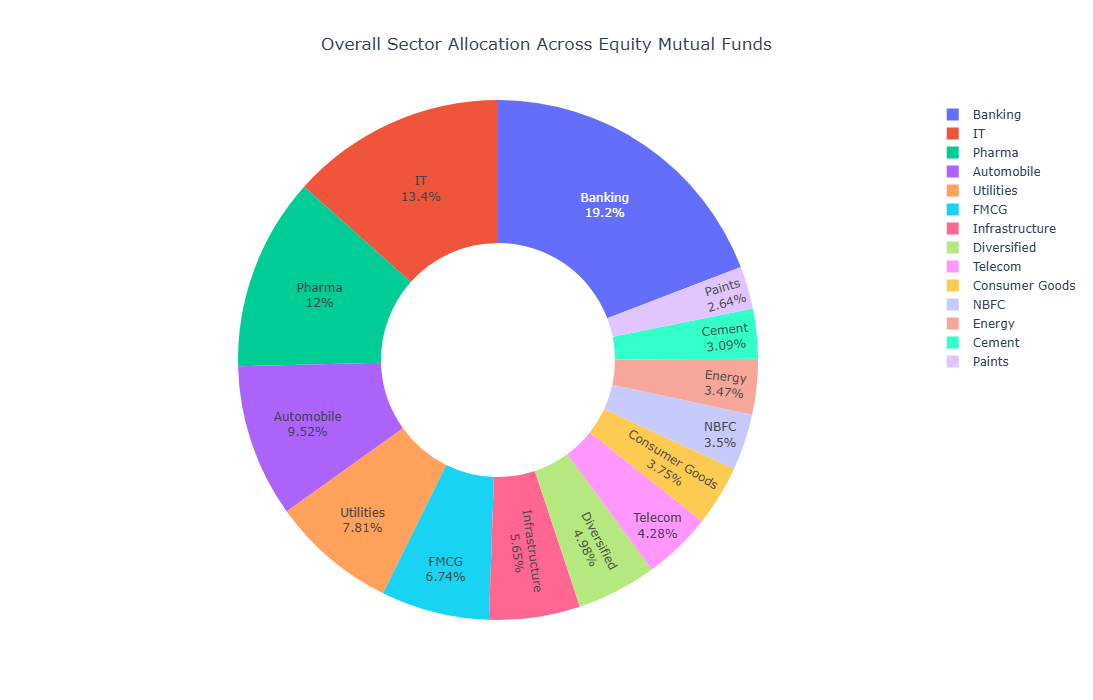

In [160]:
fig = px.pie(
    sector_allocation,
    names="sector",
    values="weight_pct",
    hole=0.45,
    title="Overall Sector Allocation Across Equity Mutual Funds"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(
    template="plotly_white",
    height=700,
    width=900,
    title_x=0.5
)

fig.show()

In [161]:
os.makedirs(
    "../reports/charts",
    exist_ok=True
)

fig.write_html(
    "../reports/charts/Sector_Allocation_Donut.html"
)

In [162]:
eda_findings = [
    "1. Daily NAV trends showed consistent long-term growth across most mutual fund schemes from 2022 to 2026.",
    
    "2. SBI Mutual Fund maintained the highest Assets Under Management (AUM), reaching approximately ₹12.5 lakh crore by 2025.",

    "3. Monthly SIP inflows increased steadily and reached an all-time high of ₹31,002 crore in December 2025.",

    "4. Equity-oriented mutual fund categories consistently attracted higher investor inflows than other categories.",

    "5. Investor demographic analysis showed strong participation across multiple age groups, with younger investors actively adopting SIP investments.",

    "6. T30 cities contributed a significant share of mutual fund investments, while B30 cities demonstrated increasing participation.",

    "7. Mutual fund folios grew from approximately 13.26 crore in January 2022 to 26.12 crore in December 2025.",

    "8. The NAV return correlation matrix indicated diversification opportunities among selected mutual fund schemes.",

    "9. Portfolio holdings showed diversified sector allocation across financial services, technology, healthcare, consumer goods, and other industries.",

    "10. Overall analysis indicates strong and consistent growth in India's mutual fund industry across NAV, AUM, SIP inflows, folios, and investor participation."
]

In [166]:

print("KEY EDA FINDINGS")


for finding in eda_findings:
    print(f"\n{finding}")

KEY EDA FINDINGS

1. Daily NAV trends showed consistent long-term growth across most mutual fund schemes from 2022 to 2026.

2. SBI Mutual Fund maintained the highest Assets Under Management (AUM), reaching approximately ₹12.5 lakh crore by 2025.

3. Monthly SIP inflows increased steadily and reached an all-time high of ₹31,002 crore in December 2025.

4. Equity-oriented mutual fund categories consistently attracted higher investor inflows than other categories.

5. Investor demographic analysis showed strong participation across multiple age groups, with younger investors actively adopting SIP investments.

6. T30 cities contributed a significant share of mutual fund investments, while B30 cities demonstrated increasing participation.

7. Mutual fund folios grew from approximately 13.26 crore in January 2022 to 26.12 crore in December 2025.

8. The NAV return correlation matrix indicated diversification opportunities among selected mutual fund schemes.

9. Portfolio holdings showed di

In [167]:
import os

os.makedirs("../reports", exist_ok=True)

with open("../reports/EDA_Findings.txt", "w", encoding="utf-8") as file:
    file.write("KEY EDA FINDINGS\n")
    file.write("=" * 80 + "\n\n")

    for finding in eda_findings:
        file.write(f"{finding}\n\n")



In [ ]:
import pandas as pd

findings_df = pd.DataFrame({
    "Finding No.": range(1, 11),
    "Key Finding": eda_findings
})

findings_df